In [738]:
import ipywidgets as widgets
from IPython.display import display
import glob
import os

# Search paths for the POST WASH directory
post_wash_paths = [
    'Fluorescence Data - OCTOBER 2024 SCR-FL/POST WASH - OCTOBER 2024 SCR-FL',
    '../Fluorescence Data - OCTOBER 2024 SCR-FL/POST WASH - OCTOBER 2024 SCR-FL',
    '/Users/cjeong1021/Auto_OPDx_Flourescence/Fluorescence Data - OCTOBER 2024 SCR-FL/POST WASH - OCTOBER 2024 SCR-FL',
    '/Users/cjeong1021/auto_opdx/Fluorescence Data - OCTOBER 2024 SCR-FL/POST WASH - OCTOBER 2024 SCR-FL',
    '.'
]

image_dir = '.'
for path in post_wash_paths:
    if os.path.isdir(path):
        image_dir = path
        break

print(f"Listing images from: {os.path.abspath(image_dir)}")

# Get all image files in the directory
image_files = (
    glob.glob(os.path.join(image_dir, "*.jpg")) +
    glob.glob(os.path.join(image_dir, "*.jpeg")) +
    glob.glob(os.path.join(image_dir, "*.png"))
)
image_files.sort()

# CreateDropdown option tuples (basename, full_path)
dropdown_options = [(os.path.basename(f), f) for f in image_files]

# Create a dropdown widget
file_dropdown = widgets.Dropdown(
    options=dropdown_options,
    value=image_files[0] if image_files else None,
    description='Image File:',
    disabled=False,
    layout={'width': 'max-content'}
)

use_circle_mask_checkbox = widgets.Checkbox(
    value=False,
    description='Use Circular Mask',
    disabled=False
)

ordering_dropdown = widgets.Dropdown(
    options=['reversed', 'standard', 'p8'],
    value='reversed',
    description='OrderingStyle:',
    disabled=False
)

refinement_method_dropdown = widgets.Dropdown(
    options=['contour', 'projection', 'best'],
    value='contour',
    description='Refinement Method:',
    disabled=False
)

grid_rows = 8
grid_cols = 8

display(file_dropdown)
display(use_circle_mask_checkbox)
display(ordering_dropdown)
display(refinement_method_dropdown)


Listing images from: /Users/cjeong1021/Auto_OPDx_Flourescence/Fluorescence Data - OCTOBER 2024 SCR-FL/POST WASH - OCTOBER 2024 SCR-FL


Dropdown(description='Image File:', layout=Layout(width='max-content'), options=(('25 uM FL 200uM P5 A.jpg', '…

Checkbox(value=False, description='Use Circular Mask')

Dropdown(description='OrderingStyle:', options=('reversed', 'standard', 'p8'), value='reversed')

Dropdown(description='Refinement Method:', options=('contour', 'projection', 'best'), value='contour')

Processing file: /Users/cjeong1021/Auto_OPDx_Flourescence/Fluorescence Data - OCTOBER 2024 SCR-FL/POST WASH - OCTOBER 2024 SCR-FL/25 uM FL 200uM P5 A.jpg


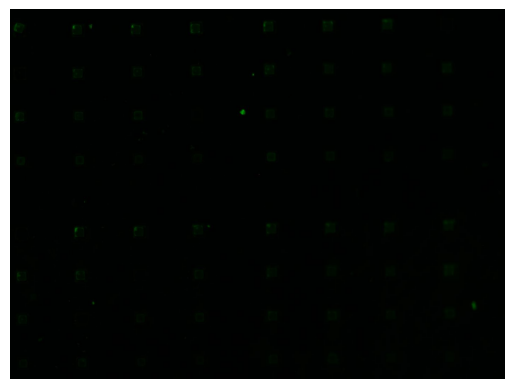

In [739]:
import cv2
import matplotlib.pyplot as plt

# Load image in BGR (OpenCV default)
filename = file_dropdown.value
print(f"Processing file: {filename}")
img_bgr = cv2.imread(filename)

# Convert BGR to RGB for Matplotlib
if img_bgr is None:
    print('Error: Could not load image. Please check the file path.')
else:
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Display the image
    plt.imshow(img_rgb)
    plt.axis('off')  # Optional: hide axis ticks


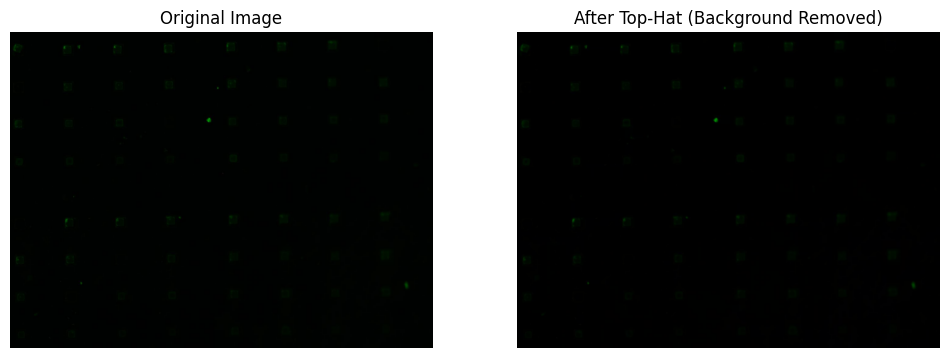

In [740]:
# Apply a median filter to the original image to reduce noise
img_median = cv2.medianBlur(img_rgb, 5)

# Define a structuring element for the Top-Hat transform
# IMPORTANT: The kernel size (here 51x51) MUST be larger than the squares you want to keep!
# Adjust the size accordingly if the squares are larger or smaller in your image.
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (51, 51))

# Apply White Top-Hat transform
# This extracts bright objects on a dark background, effectively removing uneven illumination.
# (If your squares are dark on a bright background, use cv2.MORPH_BLACKHAT instead)
img_tophat = cv2.morphologyEx(img_median, cv2.MORPH_TOPHAT, kernel)

# Display the results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_tophat)
plt.title("After Top-Hat (Background Removed)")
plt.axis("off")
plt.show()


In [ ]:
import numpy as np

# Convert to grayscale for thresholding and contour detection
gray_tophat = cv2.cvtColor(img_tophat, cv2.COLOR_RGB2GRAY)

# Threshold to isolate the bright features
_, binary_tophat = cv2.threshold(gray_tophat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Find contours
contours, _ = cv2.findContours(binary_tophat, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

filtered_contours = []
for cnt in contours:
    # Approximate contour with a polygon
    peri = cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, 0.04 * peri, True)
    
    # We are looking for square-like features, so we want polygons with 4 vertices
    if len(approx) == 4:
        # Check if the polygon is convex
        if cv2.isContourConvex(approx):
            # Compute bounding rectangle to check aspect ratio (width / height)
            x, y, w, h = cv2.boundingRect(approx)
            aspect_ratio = float(w) / h
            
            # A square will have an aspect ratio close to 1.0
            if 0.5 <= aspect_ratio <= 2.0:
                # Optional: filter by area to remove tiny noise or huge contours
                area = cv2.contourArea(cnt)
                if area > 10:  # Adjust this threshold based on actual square sizes
                    filtered_contours.append(cnt)

# Create an empty mask to draw the filtered square contours
mask = np.zeros_like(gray_tophat)
cv2.drawContours(mask, filtered_contours, -1, 255, thickness=cv2.FILLED)

# Filter out everything else using the mask on the tophat image
img_filtered = cv2.bitwise_and(img_tophat, img_tophat, mask=mask)

# Display the results
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.imshow(binary_tophat, cmap="gray")
plt.title("Thresholded Top-Hat")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title(f"Geometric Filter Mask ({len(filtered_contours)} squares)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_filtered)
plt.title("Filtered Image")
plt.axis("off")
plt.show()

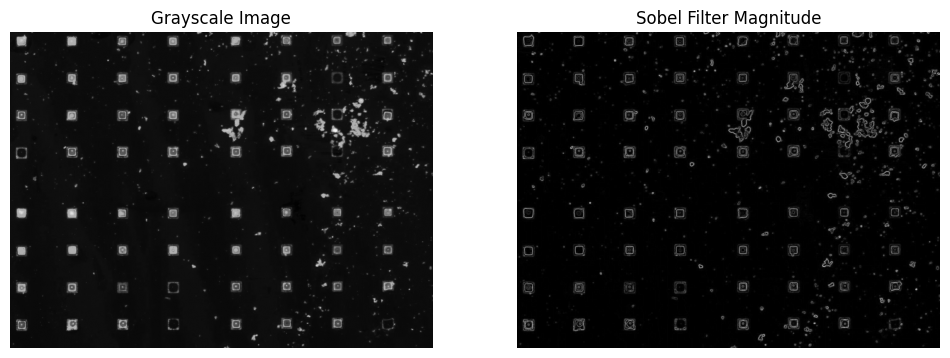

In [ ]:
# Convert original image to grayscale for Sobel edge detection
gray_img = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Apply Sobel filter in X and Y directions
sobelx = cv2.Sobel(gray_img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray_img, cv2.CV_64F, 0, 1, ksize=3)

# Calculate the gradient magnitude
sobel_magnitude = cv2.magnitude(sobelx, sobely)

# Normalize the magnitude to 0-255 for display
sobel_magnitude = cv2.normalize(sobel_magnitude, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

# Display the result
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(gray_img, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sobel_magnitude, cmap="gray")
plt.title("Sobel Filter Magnitude")
plt.axis("off")
plt.show()


(np.float64(-0.5), np.float64(1391.5), np.float64(1039.5), np.float64(-0.5))

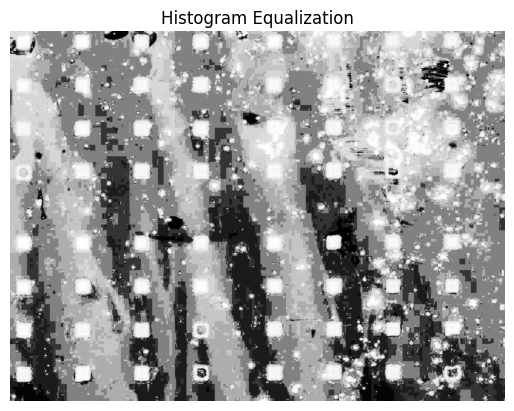

In [ ]:
# Convert to HSV color space to perform histogram equalization on the Value channel
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Equalize the V channel
img_hsv[:, :] = cv2.equalizeHist(img_hsv[:, :])

# Display the equalized image
plt.imshow(img_hsv, cmap="gray")
plt.title("Histogram Equalization")
plt.axis("off")

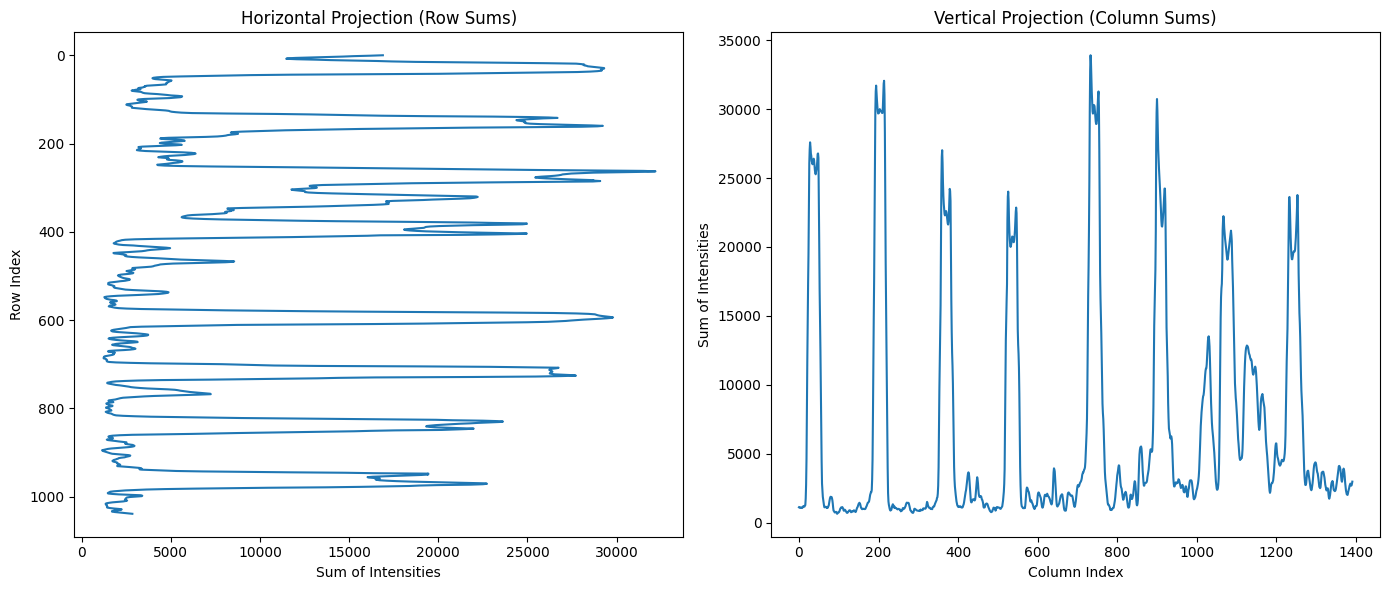

In [ ]:
# Create 1D horizontal and vertical projection map
# Accumulating pixel intensities by column (vertical projection) and row (horizontal projection)
# We will use gray_tophat which is the grayscale top hat image from the previous cell

horizontal_projection = np.sum(gray_tophat, axis=1)
vertical_projection = np.sum(gray_tophat, axis=0)

plt.figure(figsize=(14, 6))

# Visualize horizontal projection
plt.subplot(1, 2, 1)
plt.plot(horizontal_projection, range(len(horizontal_projection)))
plt.gca().invert_yaxis() # Invert y-axis to match image orientation
plt.title('Horizontal Projection (Row Sums)')
plt.xlabel('Sum of Intensities')
plt.ylabel('Row Index')

# Visualize vertical projection
plt.subplot(1, 2, 2)
plt.plot(range(len(vertical_projection)), vertical_projection)
plt.title('Vertical Projection (Column Sums)')
plt.xlabel('Column Index')
plt.ylabel('Sum of Intensities')

plt.tight_layout()
plt.show()


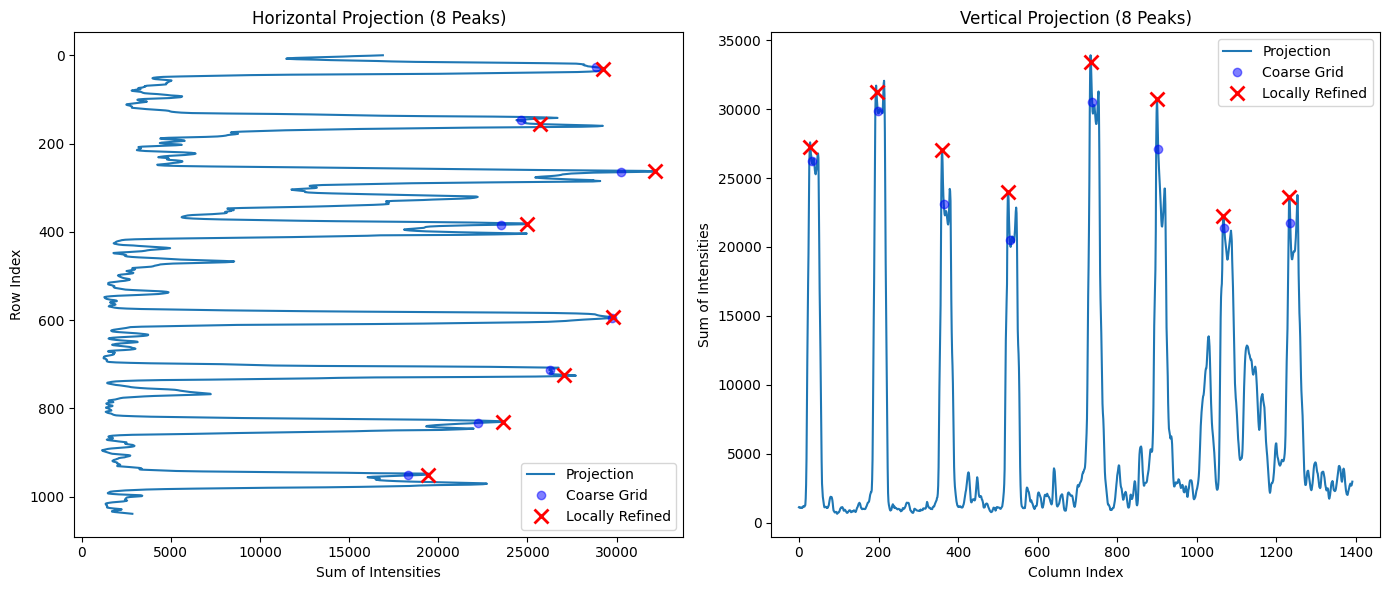

Horizontal grid row positions: [ 31 156 263 382 594 724 830 950]
Vertical grid column positions: [  29  195  360  526  734  900 1067 1233]


In [ ]:
def fit_robust_grid(projection, n_lines=8, is_horizontal=True):
    if is_horizontal:
        s_range = range(118, 129)
        g_range = range(180, 220)
        offset_range = range(10, 70)
    else:
        s_range = range(160, 175)
        g_range = range(195, 215)
        offset_range = range(10, 60)
        
    best_score = -1
    best_params = None
    smoothed = np.convolve(projection, np.ones(5)/5.0, mode='same')
    
    n_pts = len(projection)
    line_scores = np.zeros(n_pts)
    for p in range(n_pts):
        w_min = max(0, p - 5)
        w_max = min(n_pts, p + 6)
        line_scores[p] = np.sum(smoothed[w_min:w_max])
        
    for s in s_range:
        for g in g_range:
            for offset in offset_range:
                p0 = offset
                p1 = offset + s
                p2 = offset + 2 * s
                p3 = offset + 3 * s
                p4 = offset + 3 * s + g
                p5 = p4 + s
                p6 = p4 + 2 * s
                p7 = p4 + 3 * s
                
                if p7 >= n_pts:
                    continue
                    
                score = (line_scores[p0] + line_scores[p1] + line_scores[p2] + line_scores[p3] +
                         line_scores[p4] + line_scores[p5] + line_scores[p6] + line_scores[p7])
                
                if score > best_score:
                    best_score = score
                    best_params = (p0, p1, p2, p3, p4, p5, p6, p7)
                    
    if best_params is None:
        return np.linspace(0, len(projection) - 1, n_lines, dtype=int)
        
    return np.array(best_params)

def refine_grid_lines_locally(projection, coarse_lines, search_radius=10):
    refined_lines = []
    smoothed = np.convolve(projection, np.ones(5)/5.0, mode='same')
    for line in coarse_lines:
        w_min = max(0, line - search_radius)
        w_max = min(len(projection), line + search_radius + 1)
        sub_proj = smoothed[w_min:w_max]
        local_peak_idx = np.argmax(sub_proj)
        refined_val = w_min + local_peak_idx
        refined_lines.append(refined_val)
    return np.array(refined_lines)

# Find 8 local peaks (robust hybrid grid fitting) for both axes
horizontal_coarse = fit_robust_grid(horizontal_projection, grid_rows, is_horizontal=True)
vertical_coarse = fit_robust_grid(vertical_projection, grid_cols, is_horizontal=False)

horizontal_peaks = refine_grid_lines_locally(horizontal_projection, horizontal_coarse, search_radius=10)
vertical_peaks = refine_grid_lines_locally(vertical_projection, vertical_coarse, search_radius=10)

# Visualize the peaks on the projections
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(horizontal_projection, range(len(horizontal_projection)), label="Projection")
plt.plot(horizontal_projection[horizontal_coarse], horizontal_coarse, "bo", alpha=0.5, label="Coarse Grid")
plt.plot(horizontal_projection[horizontal_peaks], horizontal_peaks, "rx", markersize=10, markeredgewidth=2, label="Locally Refined")
plt.gca().invert_yaxis()
plt.title(f'Horizontal Projection ({len(horizontal_peaks)} Peaks)')
plt.xlabel('Sum of Intensities')
plt.ylabel('Row Index')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(len(vertical_projection)), vertical_projection, label="Projection")
plt.plot(vertical_coarse, vertical_projection[vertical_coarse], "bo", alpha=0.5, label="Coarse Grid")
plt.plot(vertical_peaks, vertical_projection[vertical_peaks], "rx", markersize=10, markeredgewidth=2, label="Locally Refined")
plt.title(f'Vertical Projection ({len(vertical_peaks)} Peaks)')
plt.xlabel('Column Index')
plt.ylabel('Sum of Intensities')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Horizontal grid row positions: {horizontal_peaks}")
print(f"Vertical grid column positions: {vertical_peaks}")


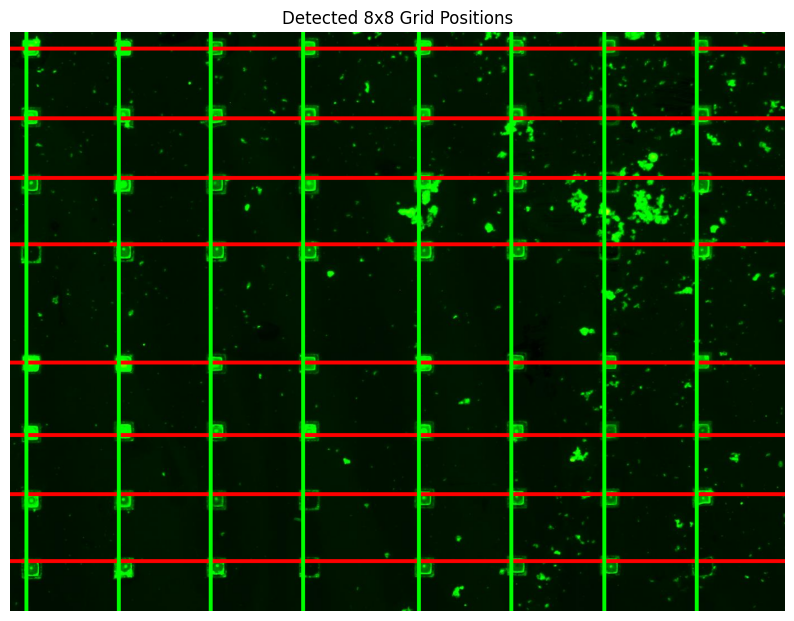

In [ ]:
# Create a copy of the original RGB image to draw the grid lines
img_grid = img_rgb.copy()

# Draw horizontal grid lines (rows) based on detected peaks
for row_idx in horizontal_peaks:
    # OpenCV uses (x, y) coordinates, so row index is y
    cv2.line(img_grid, (0, row_idx), (img_grid.shape[1], row_idx), (255, 0, 0), thickness=5) # Red lines for rows

# Draw vertical grid lines (columns) based on detected peaks
for col_idx in vertical_peaks:
    # column index is x
    cv2.line(img_grid, (col_idx, 0), (col_idx, img_grid.shape[0]), (0, 255, 0), thickness=5) # Green lines for columns

# Display the original image with the overlayed grid
plt.figure(figsize=(10, 10))
plt.imshow(img_grid)
plt.title("Detected 8x8 Grid Positions")
plt.axis("off")
plt.show()


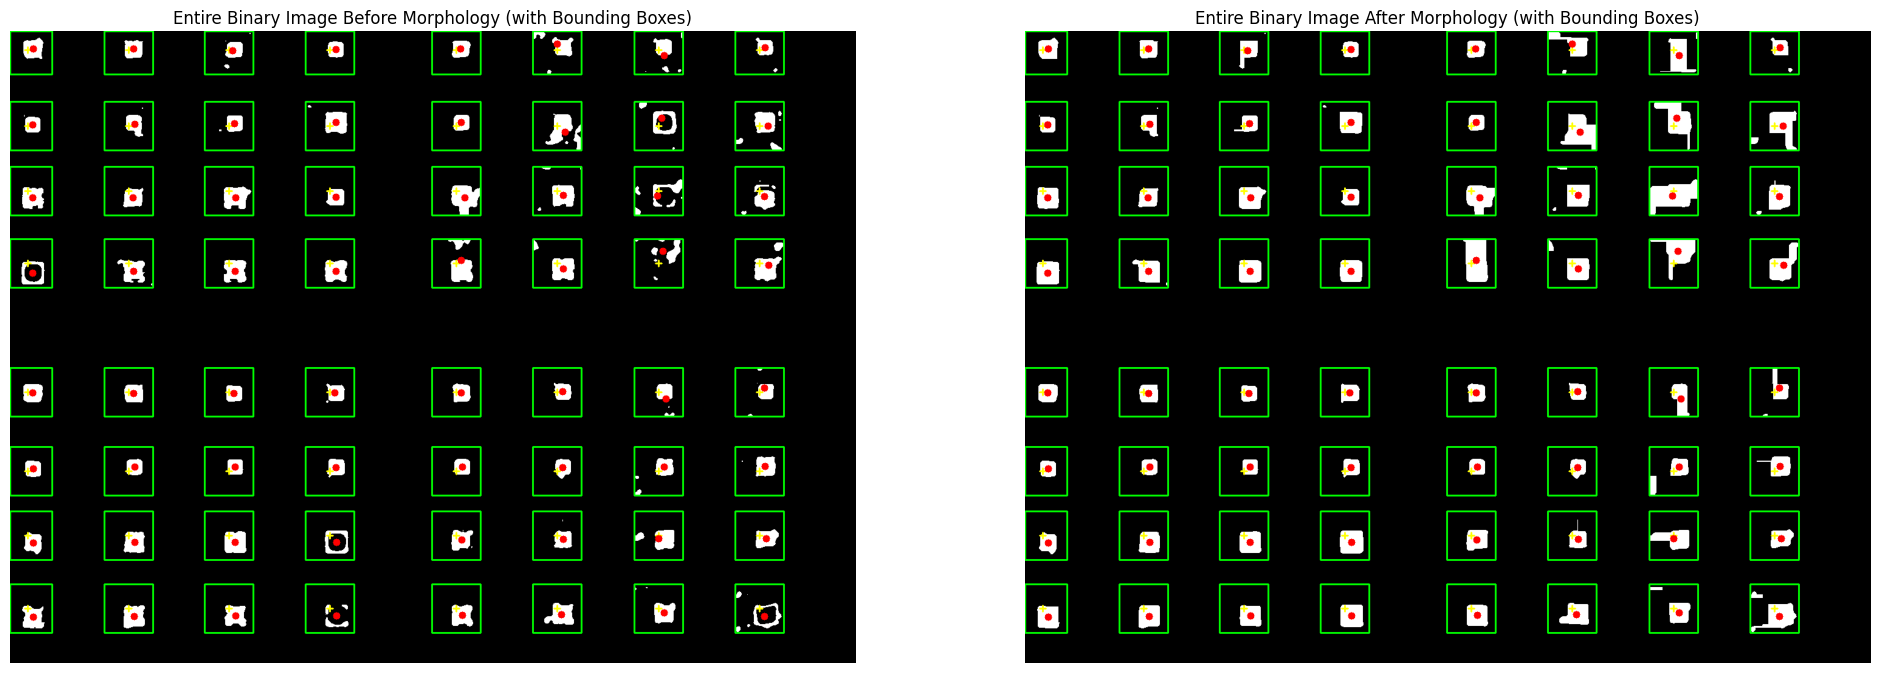

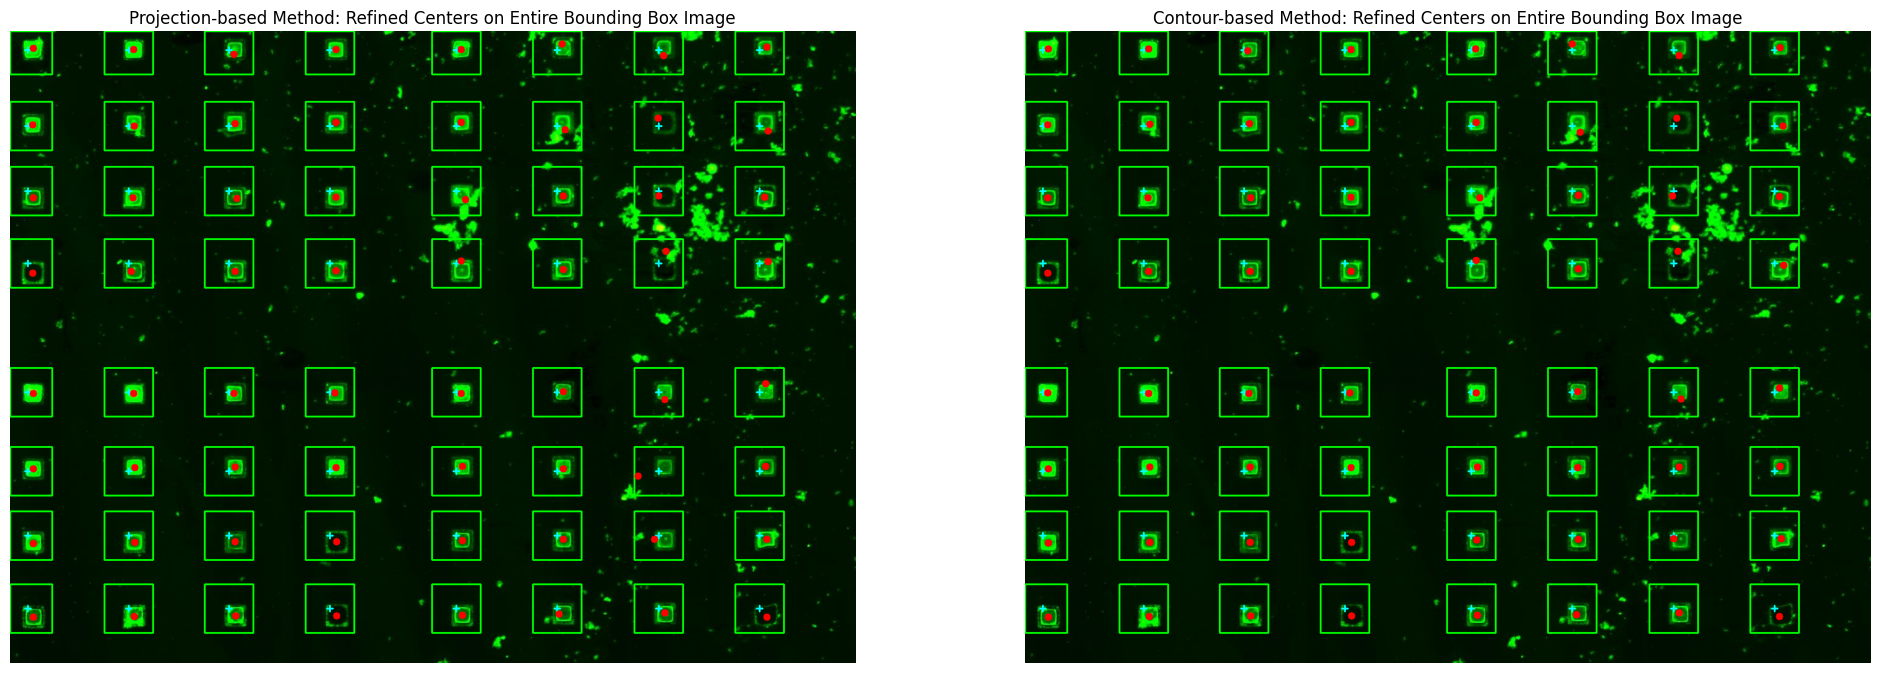

Total features detected: 64 (Grid: 8x8)
Top-left feature center (x, y): (38, 28)


In [ ]:
# Calculate refined centers using BOTH methods on BOTH binary and grayscale morphology
feature_centers_proj_bin = []
feature_centers_cont_bin = []
feature_centers_proj_gray = []
feature_centers_cont_gray = []
feature_rect_params = []
global_centers = []

# Search window size (80x80)
window_size = 80
half_w = window_size // 2

# Create blank global canvases for local binarization visualization
binary_before = np.zeros_like(gray_tophat)
binary_after = np.zeros_like(gray_tophat)

for r_idx, row_idx in enumerate(horizontal_peaks):
    row_proj_bin = []
    row_cont_bin = []
    row_proj_gray = []
    row_cont_gray = []
    row_rects = []
    global_row = []
    for c_idx, col_idx in enumerate(vertical_peaks):
        cx, cy = col_idx, row_idx
        global_row.append((cx, cy))
        
        # Local search bounds
        x_min = max(0, cx - half_w)
        x_max = min(gray_tophat.shape[1], cx + half_w)
        y_min = max(0, cy - half_w)
        y_max = min(gray_tophat.shape[0], cy + half_w)
        
        local_region = gray_tophat[y_min:y_max, x_min:x_max]
        
        # Default fallback centers
        p_cx_b, p_cy_b = cx, cy
        c_cx_b, c_cy_b = cx, cy
        p_cx_g, p_cy_g = cx, cy
        c_cx_g, c_cy_g = cx, cy
        rect_param = None
        
        if local_region.size > 0 and np.max(local_region) >= 10 and np.max(local_region) - np.min(local_region) >= 5:
            local_region_u8 = local_region.astype(np.uint8)
            ksize = max(5, int(window_size // 2) | 1)
            padded = cv2.copyMakeBorder(local_region_u8, ksize, ksize, ksize, ksize, cv2.BORDER_CONSTANT, value=0)
            _, thresh_padded = cv2.threshold(padded, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (ksize, ksize))
            closed_padded = cv2.morphologyEx(thresh_padded, cv2.MORPH_CLOSE, kernel)
            
            thresh_cropped = thresh_padded[ksize:-ksize, ksize:-ksize]
            closed_cropped = closed_padded[ksize:-ksize, ksize:-ksize]
            
            # Paste local binarized spots into global canvases
            binary_before[y_min:y_max, x_min:x_max] = thresh_cropped
            binary_after[y_min:y_max, x_min:x_max] = closed_cropped
            
            # Helper function for projection profiles
            def get_peak_center(proj, fallback_val):
                p = np.argmax(proj)
                val = proj[p]
                if val == 0:
                    return fallback_val
                thresh_val = val * 0.15
                left = p
                while left > 0 and proj[left] > thresh_val:
                    left -= 1
                right = p
                while right < len(proj) - 1 and proj[right] > thresh_val:
                    right += 1
                return (left + right) / 2.0
            
            # 1. Projection on Binary (closed_cropped)
            proj_y_b = np.sum(closed_cropped, axis=1)
            proj_x_b = np.sum(closed_cropped, axis=0)
            p_cx_b = x_min + int(round(get_peak_center(proj_x_b, cx - x_min)))
            p_cy_b = y_min + int(round(get_peak_center(proj_y_b, cy - y_min)))
            
            # 2. Projection on Grayscale (local_region)
            proj_y_g = np.sum(local_region, axis=1)
            proj_x_g = np.sum(local_region, axis=0)
            p_cx_g = x_min + int(round(get_peak_center(proj_x_g, cx - x_min)))
            p_cy_g = y_min + int(round(get_peak_center(proj_y_g, cy - y_min)))
            
            # 3. Contour on Binary (closed_cropped)
            contours_b, _ = cv2.findContours(closed_cropped, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            best_contour_b = None
            min_dist_to_center_b = float('inf')
            center_local_x = (x_max - x_min) / 2.0
            center_local_y = (y_max - y_min) / 2.0
            for cnt in contours_b:
                area = cv2.contourArea(cnt)
                if area < 20:
                    continue
                M = cv2.moments(cnt)
                if M["m00"] != 0:
                    bcx = M["m10"] / M["m00"]
                    bcy = M["m01"] / M["m00"]
                else:
                    bx, by, bw, bh = cv2.boundingRect(cnt)
                    bcx, bcy = bx + bw/2.0, by + bh/2.0
                dist = (bcx - center_local_x)**2 + (bcy - center_local_y)**2
                if dist < min_dist_to_center_b:
                    min_dist_to_center_b = dist
                    best_contour_b = cnt
            if best_contour_b is not None:
                M = cv2.moments(best_contour_b)
                if M["m00"] != 0:
                    c_cx_b = x_min + int(round(M["m10"] / M["m00"]))
                    c_cy_b = y_min + int(round(M["m01"] / M["m00"]))
                else:
                    bx, by, bw, bh = cv2.boundingRect(best_contour_b)
                    c_cx_b = x_min + int(round(bx + bw/2.0))
                    c_cy_b = y_min + int(round(by + bh/2.0))
            else:
                c_cx_b, c_cy_b = p_cx_b, p_cy_b
                
            # 4. Contour on Grayscale (thresh_cropped)
            contours_g, _ = cv2.findContours(thresh_cropped, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            best_contour_g = None
            min_dist_to_center_g = float('inf')
            for cnt in contours_g:
                area = cv2.contourArea(cnt)
                if area < 20:
                    continue
                M = cv2.moments(cnt)
                if M["m00"] != 0:
                    bcx = M["m10"] / M["m00"]
                    bcy = M["m01"] / M["m00"]
                else:
                    bx, by, bw, bh = cv2.boundingRect(cnt)
                    bcx, bcy = bx + bw/2.0, by + bh/2.0
                dist = (bcx - center_local_x)**2 + (bcy - center_local_y)**2
                if dist < min_dist_to_center_g:
                    min_dist_to_center_g = dist
                    best_contour_g = cnt
            if best_contour_g is not None:
                M = cv2.moments(best_contour_g)
                if M["m00"] != 0:
                    c_cx_g = x_min + int(round(M["m10"] / M["m00"]))
                    c_cy_g = y_min + int(round(M["m01"] / M["m00"]))
                else:
                    bx, by, bw, bh = cv2.boundingRect(best_contour_g)
                    c_cx_g = x_min + int(round(bx + bw/2.0))
                    c_cy_g = y_min + int(round(by + bh/2.0))
            else:
                c_cx_g, c_cy_g = p_cx_g, p_cy_g
                
            # Fit minimum area rectangle to locate corner center and aspect ratio from best morphological contour
            # Fall back to unclosed grayscale contour if closed contour is distorted (e.g., merged with noise)
            rect_b = cv2.minAreaRect(best_contour_b) if best_contour_b is not None else None
            rect_g = cv2.minAreaRect(best_contour_g) if best_contour_g is not None else None
            
            ar_b = max(rect_b[1]) / (min(rect_b[1]) + 1e-5) if rect_b is not None else 999.0
            ar_g = max(rect_g[1]) / (min(rect_g[1]) + 1e-5) if rect_g is not None else 999.0
            
            use_g = False
            if rect_g is not None and ar_g < 1.8:
                if rect_b is None or ar_b >= 1.8 or abs(ar_g - 1.0) < abs(ar_b - 1.0):
                    use_g = True
                    
            chosen_rect = rect_g if use_g else rect_b
            if chosen_rect is not None:
                rect_corner_cx = x_min + chosen_rect[0][0]
                rect_corner_cy = y_min + chosen_rect[0][1]
                w_rect, h_rect = chosen_rect[1]
                ar_rect = max(w_rect, h_rect) / (min(w_rect, h_rect) + 1e-5)
                rect_param = (rect_corner_cx, rect_corner_cy, ar_rect)
        row_proj_bin.append((p_cx_b, p_cy_b))
        row_cont_bin.append((c_cx_b, c_cy_b))
        row_proj_gray.append((p_cx_g, p_cy_g))
        row_cont_gray.append((c_cx_g, c_cy_g))
        row_rects.append(rect_param)
        
    feature_centers_proj_bin.append(row_proj_bin)
    feature_centers_cont_bin.append(row_cont_bin)
    feature_centers_proj_gray.append(row_proj_gray)
    feature_centers_cont_gray.append(row_cont_gray)
    feature_rect_params.append(row_rects)
    global_centers.append(global_row)

# Assign backward compatibility variables for notebook overlays
feature_centers_proj = feature_centers_proj_bin
feature_centers_cont = feature_centers_cont_bin

# Set active centers depending on the toggle
refinement_method = refinement_method_dropdown.value
if refinement_method == 'contour':
    feature_centers = feature_centers_cont_bin
elif refinement_method == 'projection':
    feature_centers = feature_centers_proj_bin
else:
    # 'best' 4-candidate selector
    feature_centers = []
    for r_idx in range(len(horizontal_peaks)):
        row = []
        for c_idx in range(len(vertical_peaks)):
            cx, cy = vertical_peaks[c_idx], horizontal_peaks[r_idx]
            ccx_b, ccy_b = feature_centers_cont_bin[r_idx][c_idx]
            pcx_b, pcy_b = feature_centers_proj_bin[r_idx][c_idx]
            ccx_g, ccy_g = feature_centers_cont_gray[r_idx][c_idx]
            pcx_g, pcy_g = feature_centers_proj_gray[r_idx][c_idx]
            
            candidates = [
                (ccx_b, ccy_b, "Contour_Binary"),
                (pcx_b, pcy_b, "Projection_Binary"),
                (ccx_g, ccy_g, "Contour_Gray"),
                (pcx_g, pcy_g, "Projection_Gray")
            ]
            
            rect_param = feature_rect_params[r_idx][c_idx]
            if rect_param is not None:
                corner_cx, corner_cy, aspect_ratio = rect_param
            else:
                corner_cx, corner_cy, aspect_ratio = ccx_b, ccy_b, 1.0
                
            def get_mean_intensity(img, cx, cy, box_w=20):
                hw = box_w // 2
                x_min_l = max(0, cx - hw)
                x_max_l = min(img.shape[1], cx + hw)
                y_min_l = max(0, cy - hw)
                y_max_l = min(img.shape[0], cy + hw)
                region = img[y_min_l:y_max_l, x_min_l:x_max_l]
                if region.size == 0:
                    return 0.0
                return float(np.mean(region))
                
            def compute_confidence(mean_val, dist_to_grid, dist_to_corner, aspect_ratio, dist_to_consensus=0.0):
                penalty_corner = dist_to_corner * 2.0
                penalty_ar = (aspect_ratio - 1.0) * 15.0
                penalty_consensus = dist_to_consensus * 1.0
                penalty_grid = 0.0
                if dist_to_grid > 15:
                    penalty_grid = (dist_to_grid - 15) * 2.0
                if dist_to_grid > 30:
                    penalty_grid += 100.0
                return mean_val - penalty_corner - penalty_ar - penalty_grid - penalty_consensus
                
            # Candidate consensus: compute median position
            cand_xs = [c[0] for c in candidates]
            cand_ys = [c[1] for c in candidates]
            median_x = np.median(cand_xs)
            median_y = np.median(cand_ys)
            
            best_cand_pt = (pcx_b, pcy_b)
            best_score_pt = -float('inf')
            for cand_x, cand_y, name in candidates:
                dist_to_grid = np.sqrt((cand_x - cx)**2 + (cand_y - cy)**2)
                dist_to_corner = np.sqrt((cand_x - corner_cx)**2 + (cand_y - corner_cy)**2) if rect_param is not None else 0.0
                dist_to_consensus = np.sqrt((cand_x - median_x)**2 + (cand_y - median_y)**2)
                score = compute_confidence(
                    get_mean_intensity(gray_tophat, cand_x, cand_y, 20),
                    dist_to_grid,
                    dist_to_corner,
                    aspect_ratio if rect_param is not None else 1.0,
                    dist_to_consensus
                )
                if score > best_score_pt:
                    best_score_pt = score
                    best_cand_pt = (cand_x, cand_y)
            row.append(best_cand_pt)
        feature_centers.append(row)
    
    # Apply RANSAC-fit Affine Grid Correction for robust center location
def correct_centers_with_affine_ransac(feature_centers, threshold=5.0):
    if len(feature_centers) != 8 or any(len(row) != 8 for row in feature_centers):
        return feature_centers
    A = []
    bx = []
    by = []
    for r_idx in range(8):
        for c_idx in range(8):
            rcx, rcy = feature_centers[r_idx][c_idx]
            quad_c = 1.0 if c_idx >= 4 else 0.0
            quad_r = 1.0 if r_idx >= 4 else 0.0
            A.append([r_idx, c_idx, quad_r, quad_c, 1.0])
            bx.append(rcx)
            by.append(rcy)
    A = np.array(A)
    bx = np.array(bx)
    by = np.array(by)
    
    best_inliers_count = -1
    best_model_x = None
    best_model_y = None
    np.random.seed(42)
    for _ in range(200):
        idx = np.random.choice(64, 5, replace=False)
        try:
            mx = np.linalg.lstsq(A[idx], bx[idx], rcond=None)[0]
            my = np.linalg.lstsq(A[idx], by[idx], rcond=None)[0]
        except np.linalg.LinAlgError:
            continue
        pred_x = A @ mx
        pred_y = A @ my
        err = np.sqrt((bx - pred_x)**2 + (by - pred_y)**2)
        inliers_count = np.sum(err < threshold)
        if inliers_count > best_inliers_count:
            best_inliers_count = inliers_count
            best_model_x = mx
            best_model_y = my
            
    if best_model_x is None or best_model_y is None:
        mx = np.linalg.lstsq(A, bx, rcond=None)[0]
        my = np.linalg.lstsq(A, by, rcond=None)[0]
    else:
        pred_x = A @ best_model_x
        pred_y = A @ best_model_y
        err = np.sqrt((bx - pred_x)**2 + (by - pred_y)**2)
        inliers = err < threshold
        if np.sum(inliers) >= 5:
            mx = np.linalg.lstsq(A[inliers], bx[inliers], rcond=None)[0]
            my = np.linalg.lstsq(A[inliers], by[inliers], rcond=None)[0]
        else:
            mx, my = best_model_x, best_model_y
            
    pred_x = A @ mx
    pred_y = A @ my
    err = np.sqrt((bx - pred_x)**2 + (by - pred_y)**2)
    
    corrected = []
    for r_idx in range(8):
        row = []
        for c_idx in range(8):
            idx = r_idx * 8 + c_idx
            rcx, rcy = feature_centers[r_idx][c_idx]
            if err[idx] > threshold:
                row.append((int(round(pred_x[idx])), int(round(pred_y[idx]))))
            else:
                row.append((rcx, rcy))
        corrected.append(row)
    return corrected
    
raw_feature_centers = [[(cx, cy) for cx, cy in row] for row in feature_centers]

feature_centers = correct_centers_with_affine_ransac(feature_centers, threshold=5.0)

img_before_show = cv2.cvtColor(binary_before, cv2.COLOR_GRAY2RGB)
img_after_show = cv2.cvtColor(binary_after, cv2.COLOR_GRAY2RGB)
img_proj_overlay = img_rgb.copy()
img_cont_overlay = img_rgb.copy()

for r_idx, row_idx in enumerate(horizontal_peaks):
    for c_idx, col_idx in enumerate(vertical_peaks):
        cx, cy = col_idx, row_idx
        p_cx, p_cy = feature_centers_proj[r_idx][c_idx]
        c_cx, c_cy = feature_centers_cont[r_idx][c_idx]
        
        x_min = max(0, cx - half_w)
        x_max = min(gray_tophat.shape[1], cx + half_w)
        y_min = max(0, cy - half_w)
        y_max = min(gray_tophat.shape[0], cy + half_w)
        
        # Draw on BEFORE/AFTER binarized images
        cv2.rectangle(img_before_show, (x_min, y_min), (x_max, y_max), color=(0, 255, 0), thickness=2)
        cv2.drawMarker(img_before_show, (cx, cy), color=(255, 255, 0), markerType=cv2.MARKER_CROSS, markerSize=10, thickness=2)
        cv2.circle(img_before_show, (c_cx, c_cy), radius=6, color=(255, 0, 0), thickness=-1)
        
        cv2.rectangle(img_after_show, (x_min, y_min), (x_max, y_max), color=(0, 255, 0), thickness=2)
        cv2.drawMarker(img_after_show, (cx, cy), color=(255, 255, 0), markerType=cv2.MARKER_CROSS, markerSize=10, thickness=2)
        cv2.circle(img_after_show, (c_cx, c_cy), radius=6, color=(255, 0, 0), thickness=-1)
        
        # Draw on projection overlay image
        cv2.rectangle(img_proj_overlay, (x_min, y_min), (x_max, y_max), color=(0, 255, 0), thickness=2)
        cv2.drawMarker(img_proj_overlay, (cx, cy), color=(0, 255, 255), markerType=cv2.MARKER_CROSS, markerSize=10, thickness=2)
        cv2.circle(img_proj_overlay, (p_cx, p_cy), radius=6, color=(255, 0, 0), thickness=-1)
        
        # Draw on contour overlay image
        cv2.rectangle(img_cont_overlay, (x_min, y_min), (x_max, y_max), color=(0, 255, 0), thickness=2)
        cv2.drawMarker(img_cont_overlay, (cx, cy), color=(0, 255, 255), markerType=cv2.MARKER_CROSS, markerSize=10, thickness=2)
        cv2.circle(img_cont_overlay, (c_cx, c_cy), radius=6, color=(255, 0, 0), thickness=-1)

# Plot the entire binarized image before and after morphology side-by-side
plt.figure(figsize=(24, 12))
plt.subplot(1, 2, 1)
plt.imshow(img_before_show)
plt.title("Entire Binary Image Before Morphology (with Bounding Boxes)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_after_show)
plt.title("Entire Binary Image After Morphology (with Bounding Boxes)")
plt.axis('off')
plt.show()

# Plot BOTH overlays side-by-side showing the entire original image
plt.figure(figsize=(24, 12))
plt.subplot(1, 2, 1)
plt.imshow(img_proj_overlay)
plt.title("Projection-based Method: Refined Centers on Entire Bounding Box Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_cont_overlay)
plt.title("Contour-based Method: Refined Centers on Entire Bounding Box Image")
plt.axis('off')
plt.show()

print(f"Total features detected: {len(feature_centers) * len(feature_centers[0])} (Grid: {len(feature_centers)}x{len(feature_centers[0])})")
print(f"Top-left feature center (x, y): {feature_centers[0][0]}")


## RANSAC Affine Grid Correction

To handle spots in noisy background regions (where centroid refinement gets pulled away by adjacent green fluorescence noise blobs), we fit a global 2D affine model to the refined spot centers using robust **RANSAC (Random Sample Consensus)**.

Any spot whose local centroid deviates from the global model prediction by more than **5.0 pixels** is flagged as an outlier and corrected back to the predicted grid intersection. This guarantees robust measurements on all plates.


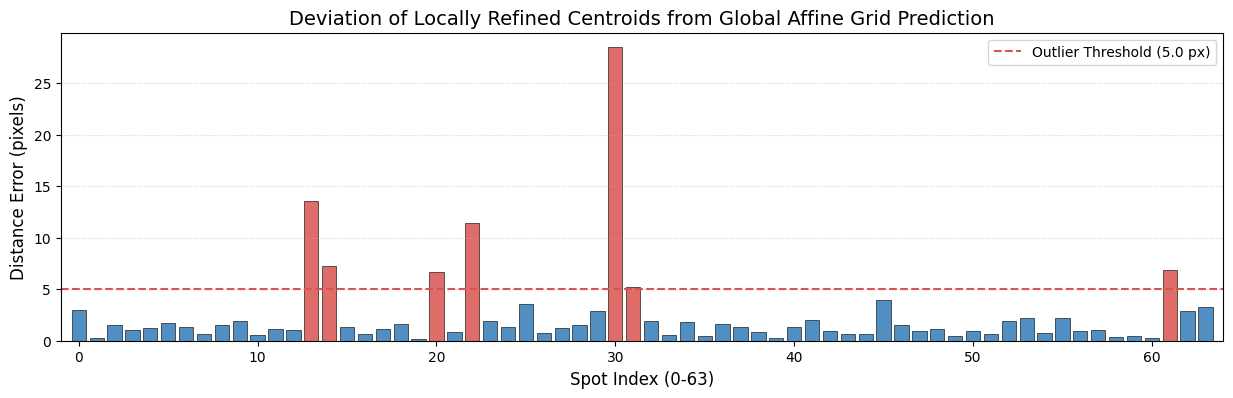

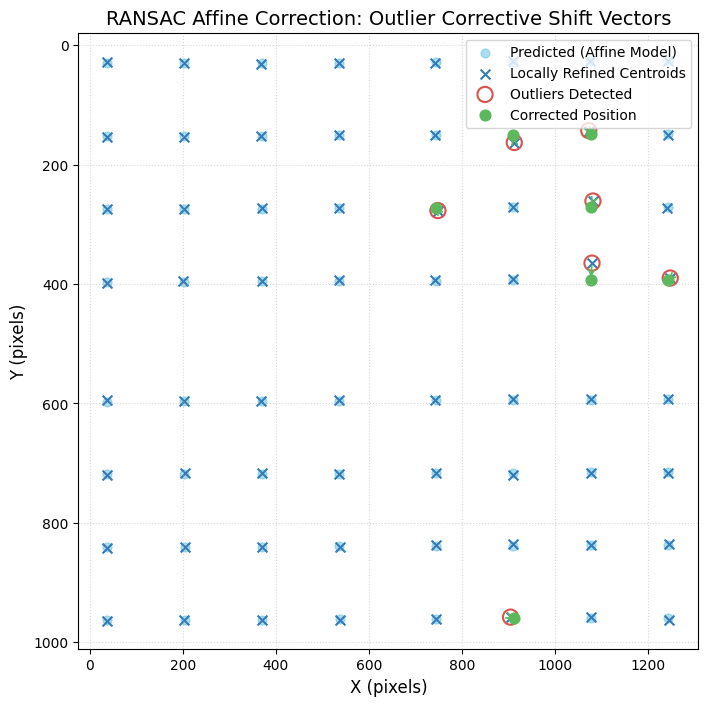

RANSAC Affine Grid Correction detected and shifted 7 outlier spot(s):
  * Spot R1C5: Raw Refined=(912.0, 163.0) -> Corrected=(909.5, 149.7) | Shift=13.56 px
  * Spot R1C6: Raw Refined=(1072.0, 143.0) -> Corrected=(1075.9, 149.2) | Shift=7.30 px
  * Spot R2C4: Raw Refined=(748.0, 277.0) -> Corrected=(743.3, 272.2) | Shift=6.70 px
  * Spot R2C6: Raw Refined=(1081.0, 261.0) -> Corrected=(1076.1, 271.3) | Shift=11.39 px
  * Spot R3C6: Raw Refined=(1079.0, 365.0) -> Corrected=(1076.3, 393.3) | Shift=28.48 px
  * Spot R3C7: Raw Refined=(1247.0, 390.0) -> Corrected=(1242.7, 392.9) | Shift=5.19 px
  * Spot R7C5: Raw Refined=(904.0, 958.0) -> Corrected=(910.5, 960.2) | Shift=6.87 px


In [ ]:
# Visualizing RANSAC affine correction results
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare design matrix and observations from uncorrected centers
A = []
bx = []
by = []
for r_idx in range(8):
    for c_idx in range(8):
        rcx, rcy = raw_feature_centers[r_idx][c_idx]
        quad_c = 1.0 if c_idx >= 4 else 0.0
        quad_r = 1.0 if r_idx >= 4 else 0.0
        A.append([r_idx, c_idx, quad_r, quad_c, 1.0])
        bx.append(rcx)
        by.append(rcy)
A = np.array(A)
bx = np.array(bx)
by = np.array(by)

# 2. Solve RANSAC models
best_inliers_count = -1
best_model_x = None
best_model_y = None
np.random.seed(42)
for _ in range(200):
    idx = np.random.choice(64, 5, replace=False)
    try:
        mx = np.linalg.lstsq(A[idx], bx[idx], rcond=None)[0]
        my = np.linalg.lstsq(A[idx], by[idx], rcond=None)[0]
    except np.linalg.LinAlgError:
        continue
    pred_x = A @ mx
    pred_y = A @ my
    err = np.sqrt((bx - pred_x)**2 + (by - pred_y)**2)
    inliers_count = np.sum(err < 5.0)
    if inliers_count > best_inliers_count:
        best_inliers_count = inliers_count
        best_model_x = mx
        best_model_y = my

if best_model_x is not None and best_model_y is not None:
    pred_x = A @ best_model_x
    pred_y = A @ best_model_y
    err = np.sqrt((bx - pred_x)**2 + (by - pred_y)**2)
    inliers = err < 5.0
    if np.sum(inliers) >= 5:
        mx = np.linalg.lstsq(A[inliers], bx[inliers], rcond=None)[0]
        my = np.linalg.lstsq(A[inliers], by[inliers], rcond=None)[0]
        pred_x = A @ mx
        pred_y = A @ my
        err = np.sqrt((bx - pred_x)**2 + (by - pred_y)**2)

# 3. Plot deviations bar chart
plt.figure(figsize=(15, 4))
colors = ['#d9534f' if e > 5.0 else '#337ab7' for e in err]
plt.bar(range(64), err, color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
plt.axhline(5.0, color='#d9534f', linestyle='--', linewidth=1.5, label='Outlier Threshold (5.0 px)')
plt.title('Deviation of Locally Refined Centroids from Global Affine Grid Prediction', fontsize=14)
plt.xlabel('Spot Index (0-63)', fontsize=12)
plt.ylabel('Distance Error (pixels)', fontsize=12)
plt.xlim(-1, 64)
plt.grid(True, axis='y', linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.show()

# 4. Plot 2D scatter comparison
plt.figure(figsize=(8, 8))
plt.scatter(pred_x, pred_y, color='#5bc0de', s=40, label='Predicted (Affine Model)', alpha=0.5)
plt.scatter(bx, by, color='#337ab7', marker='x', s=50, label='Locally Refined Centroids')
outliers = np.where(err > 5.0)[0]
if len(outliers) > 0:
    plt.scatter(bx[outliers], by[outliers], facecolors='none', edgecolors='#d9534f', s=120, linewidths=1.5, label='Outliers Detected')
    plt.scatter(pred_x[outliers], pred_y[outliers], color='#5cb85c', marker='o', s=60, label='Corrected Position')
    for o in outliers:
        plt.annotate('', xy=(pred_x[o], pred_y[o]), xytext=(bx[o], by[o]),
                     arrowprops=dict(arrowstyle="->", color='#5cb85c', lw=1.2))
plt.title('RANSAC Affine Correction: Outlier Corrective Shift Vectors', fontsize=14)
plt.xlabel('X (pixels)', fontsize=12)
plt.ylabel('Y (pixels)', fontsize=12)
plt.gca().invert_yaxis()
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper right')
plt.show()

# 5. Print log details
if len(outliers) > 0:
    print(f"RANSAC Affine Grid Correction detected and shifted {len(outliers)} outlier spot(s):")
    for o in outliers:
        r_o = o // 8
        c_o = o % 8
        print(f"  * Spot R{r_o}C{c_o}: Raw Refined=({bx[o]:.1f}, {by[o]:.1f}) -> Corrected=({pred_x[o]:.1f}, {pred_y[o]:.1f}) | Shift={err[o]:.2f} px")
else:
    print("Consensus status: All spots aligned within 5.0 pixels of the global affine layout. No coordinates corrected.")


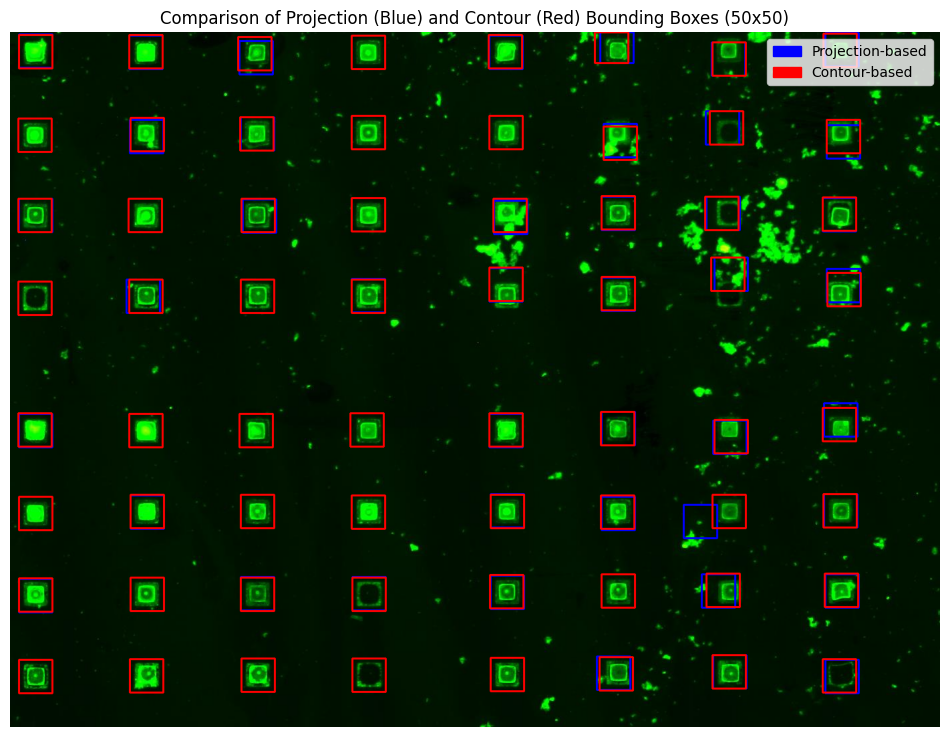

In [ ]:
# Define a fixed box size based on the square features (e.g., 15x15 pixels)
box_width = 50
box_height = 50

img_boxes = img_rgb.copy()
hw = box_width // 2
hh = box_height // 2

# Draw projection-based bounding boxes in Blue
for row in feature_centers_proj:
    for cx, cy in row:
        top_left = (max(0, cx - hw), max(0, cy - hh))
        bottom_right = (min(img_boxes.shape[1], cx + hw), min(img_boxes.shape[0], cy + hh))
        cv2.rectangle(img_boxes, top_left, bottom_right, (0, 0, 255), thickness=2)

# Draw contour-based bounding boxes in Red
for row in feature_centers_cont:
    for cx, cy in row:
        top_left = (max(0, cx - hw), max(0, cy - hh))
        bottom_right = (min(img_boxes.shape[1], cx + hw), min(img_boxes.shape[0], cy + hh))
        cv2.rectangle(img_boxes, top_left, bottom_right, (255, 0, 0), thickness=2)
        
# Display the result
plt.figure(figsize=(12, 12))
plt.imshow(img_boxes)
plt.title(f"Comparison of Projection (Blue) and Contour (Red) Bounding Boxes ({box_width}x{box_height})")

# Add a legend
import matplotlib.patches as mpatches
proj_patch = mpatches.Patch(color='blue', label='Projection-based')
cont_patch = mpatches.Patch(color='red', label='Contour-based')
plt.legend(handles=[proj_patch, cont_patch], loc='upper right')

plt.axis("off")
plt.show()


## Confidence Scoring Method Explanation

To automatically choose the best center for each spot, we evaluate **four candidate refinement methods** for each spot and select the coordinate with the highest **Confidence Score**.

### The 4 Candidate Coordinates Evaluated:
1. **Contour on Binary**: Moment centroid on the morphological closed binary image (`closed`).
2. **Projection on Binary**: Profile midpoint on the morphological closed binary image (`closed`).
3. **Contour on Grayscale**: Moment centroid on the Otsu-thresholded grayscale image (`thresh_cropped`).
4. **Projection on Grayscale**: Profile midpoint on the raw grayscale background-subtracted image (`local_region`).

### The Confidence Score Formula

For each candidate $(x_c, y_c)$:

$$ \text{Confidence} = \text{Signal Strength} - \text{Penalty}_{corner} - \text{Penalty}_{AR} - \text{Penalty}_{grid} - \text{Penalty}_{consensus} $$

1. **Signal Strength (Local Mean Grayscale Intensity)**:
   We compute the mean intensity of the background-subtracted `gray_tophat` image in a small $20 \times 20$ pixel window centered at $(x_c, y_c).
   
2. **Corner Distance Penalty ($\text{Penalty}_{corner}$)**:
   Euclidean distance $D_{corner}$ from candidate center to the corner-based geometric midpoint $(x_{corner}, y_{corner})$ of the morphological contour:
   $$ \text{Penalty}_{corner} = D_{corner} \times 2.0 $$
   
3. **Aspect Ratio Penalty ($\text{Penalty}_{AR}$)**:
   Aspect ratio penalty ($AR = \max(w,h)/\min(w,h)$) of the morphological contour to penalize noise:
   $$ \text{Penalty}_{AR} = (AR - 1.0) \times 15.0 $$
   
4. **Grid Deviation Penalty ($\text{Penalty}_{grid}$)**:
   Penalizes distance $D_{grid}$ from the candidate to the initial grid guess.

5. **Consensus Penalty ($\text{Penalty}_{consensus}$)**:
   Penalizes distance $D_{consensus}$ from the candidate to the median position of all four candidates:
   $$ \text{Penalty}_{consensus} = D_{consensus} \times 1.0 $$


/var/folders/32/_90ffnqs6xq978t0jt6gcgdr0000gn/T/ipykernel_1141/117894139.py:120: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


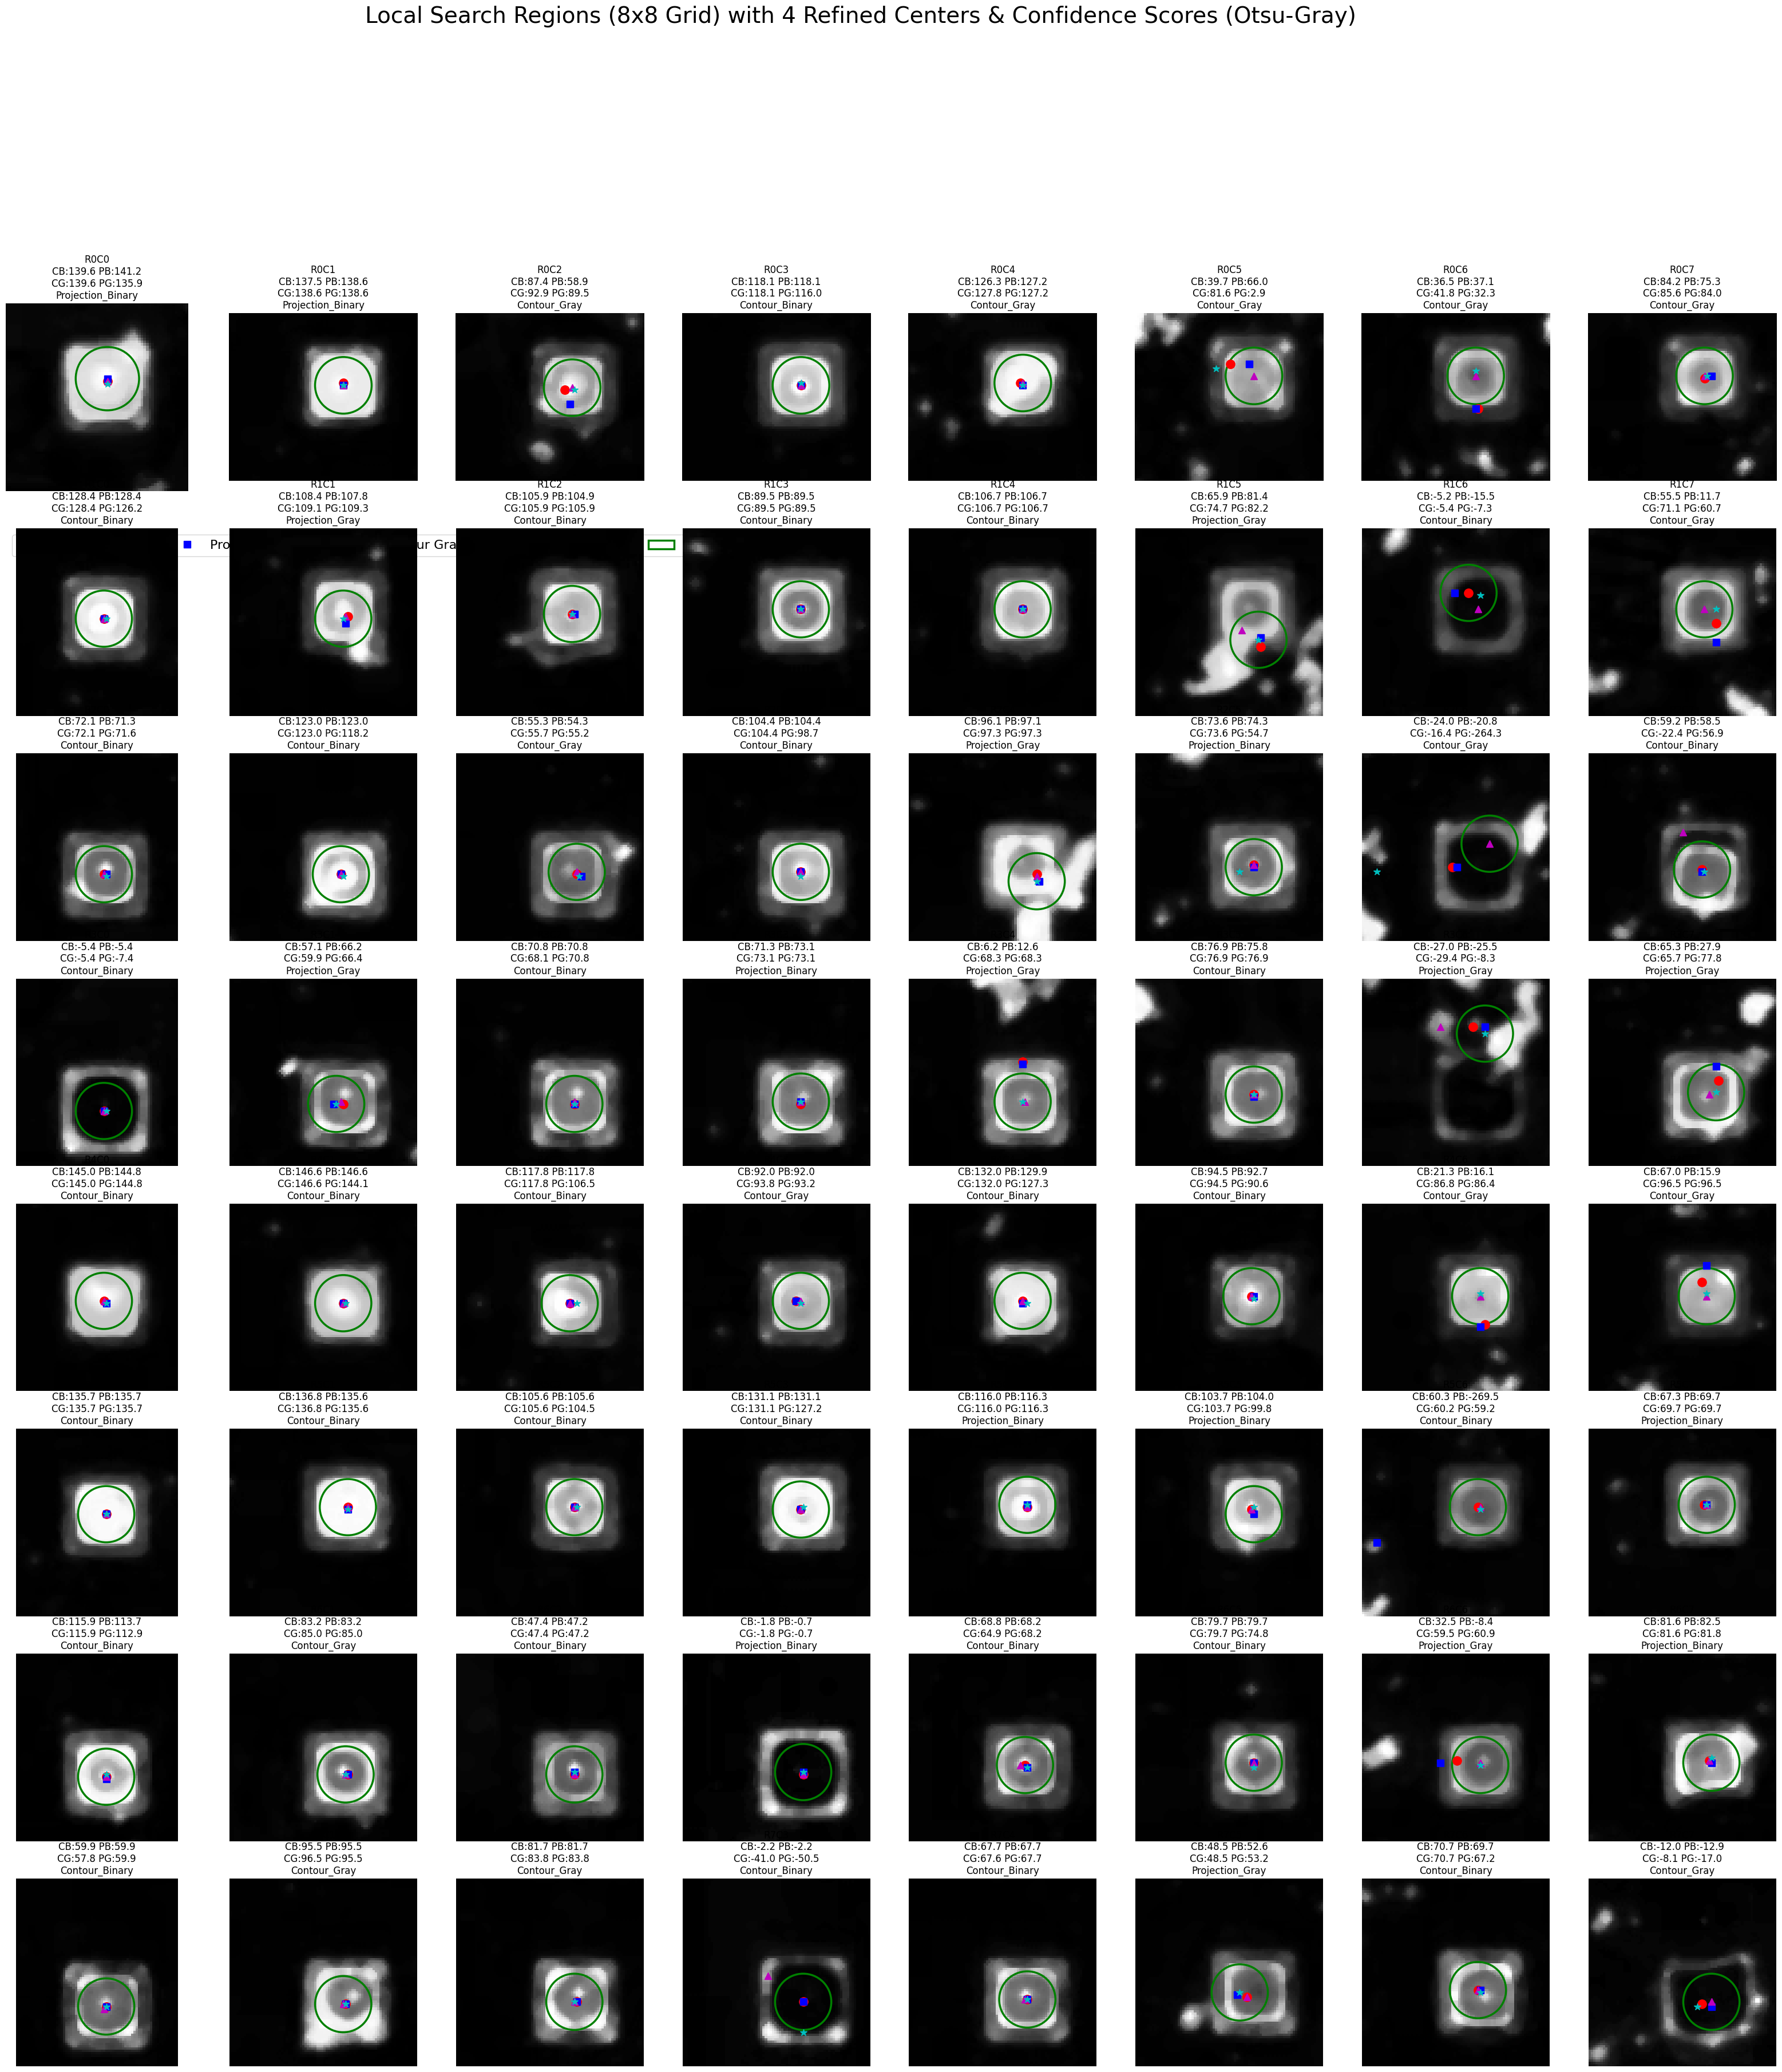

In [ ]:
# Visualizing and explaining confidence scoring
# Let's inspect all spots in an 8x8 grid, showing their 4 candidate coordinates and confidence scores
import matplotlib.patches as patches

def get_mean_intensity(img, cx, cy, box_w=20):
    hw = box_w // 2
    x_min_l = max(0, cx - hw)
    x_max_l = min(img.shape[1], cx + hw)
    y_min_l = max(0, cy - hw)
    y_max_l = min(img.shape[0], cy + hw)
    region = img[y_min_l:y_max_l, x_min_l:x_max_l]
    if region.size == 0:
        return 0.0
    return float(np.mean(region))

def compute_confidence(mean_val, dist_to_grid, dist_to_corner=0.0, aspect_ratio=1.0, dist_to_consensus=0.0):
    penalty_corner = dist_to_corner * 2.0
    penalty_ar = (aspect_ratio - 1.0) * 15.0
    penalty_consensus = dist_to_consensus * 1.0
    
    penalty_grid = 0.0
    if dist_to_grid > 15:
        penalty_grid = (dist_to_grid - 15) * 2.0
    if dist_to_grid > 30:
        penalty_grid += 100.0
        
    return mean_val - penalty_corner - penalty_ar - penalty_grid - penalty_consensus

fig, axes = plt.subplots(8, 8, figsize=(40, 40))
for r_idx in range(8):
    for c_idx in range(8):
        cx, cy = vertical_peaks[c_idx], horizontal_peaks[r_idx]
        ccx_b, ccy_b = feature_centers_cont_bin[r_idx][c_idx]
        pcx_b, pcy_b = feature_centers_proj_bin[r_idx][c_idx]
        ccx_g, ccy_g = feature_centers_cont_gray[r_idx][c_idx]
        pcx_g, pcy_g = feature_centers_proj_gray[r_idx][c_idx]
        
        # Crop local 80x80 area from gray_tophat
        hw_local = 40
        x_min_crop = max(0, cx - hw_local)
        x_max_crop = min(gray_tophat.shape[1], cx + hw_local)
        y_min_crop = max(0, cy - hw_local)
        y_max_crop = min(gray_tophat.shape[0], cy + hw_local)
        local_crop = gray_tophat[y_min_crop:y_max_crop, x_min_crop:x_max_crop]
        
        # Get corner params
        rect_param = feature_rect_params[r_idx][c_idx]
        if rect_param is not None:
            corner_cx, corner_cy, aspect_ratio = rect_param
        else:
            corner_cx, corner_cy, aspect_ratio = ccx_b, ccy_b, 1.0
            
        # Evaluate all 4 candidates
        candidates = [
            (ccx_b, ccy_b, "Contour_Binary"),
            (pcx_b, pcy_b, "Projection_Binary"),
            (ccx_g, ccy_g, "Contour_Gray"),
            (pcx_g, pcy_g, "Projection_Gray")
        ]
        
        # Candidate consensus: compute median position
        cand_xs = [c[0] for c in candidates]
        cand_ys = [c[1] for c in candidates]
        median_x = np.median(cand_xs)
        median_y = np.median(cand_ys)
        
        best_name = "Projection_Binary"
        best_score_val = -float('inf')
        best_coords = (pcx_b, pcy_b)
        scores_dict = {}
        
        for cand_x, cand_y, name in candidates:
            dist_to_grid = np.sqrt((cand_x - cx)**2 + (cand_y - cy)**2)
            dist_to_corner = np.sqrt((cand_x - corner_cx)**2 + (cand_y - corner_cy)**2) if rect_param is not None else 0.0
            dist_to_consensus = np.sqrt((cand_x - median_x)**2 + (cand_y - median_y)**2)
            score = compute_confidence(
                get_mean_intensity(gray_tophat, cand_x, cand_y, 20),
                dist_to_grid,
                dist_to_corner,
                aspect_ratio if rect_param is not None else 1.0,
                dist_to_consensus
            )
            scores_dict[name] = score
            if score > best_score_val:
                best_score_val = score
                best_coords = (cand_x, cand_y)
                best_name = name
                
        ax = axes[r_idx, c_idx]
        ax.imshow(local_crop, cmap='gray')
        
        # Local offsets
        lc_cb = (ccx_b - x_min_crop, ccy_b - y_min_crop)
        lc_pb = (pcx_b - x_min_crop, pcy_b - y_min_crop)
        lc_cg = (ccx_g - x_min_crop, ccy_g - y_min_crop)
        lc_pg = (pcx_g - x_min_crop, pcy_g - y_min_crop)
        
        # Plot candidates
        ax.plot(lc_cb[0], lc_cb[1], 'ro', markersize=11, label='Contour Binary' if (r_idx==0 and c_idx==0) else "")
        ax.plot(lc_pb[0], lc_pb[1], 'bs', markersize=9, label='Projection Binary' if (r_idx==0 and c_idx==0) else "")
        ax.plot(lc_cg[0], lc_cg[1], 'm^', markersize=9, label='Contour Gray' if (r_idx==0 and c_idx==0) else "")
        ax.plot(lc_pg[0], lc_pg[1], 'c*', markersize=9, label='Projection Gray' if (r_idx==0 and c_idx==0) else "")
        
        # Highlight chosen center
        chosen_x = best_coords[0] - x_min_crop
        chosen_y = best_coords[1] - y_min_crop
        circ = patches.Circle((chosen_x, chosen_y), radius=12, linewidth=2.5, edgecolor='g', facecolor='none', label='Chosen' if (r_idx==0 and c_idx==0) else "")
        ax.add_patch(circ)
        
        # Short abbreviation for titles
        title_str = (f"R{r_idx}C{c_idx}\n"
                     f"CB:{scores_dict['Contour_Binary']:.1f} PB:{scores_dict['Projection_Binary']:.1f}\n"
                     f"CG:{scores_dict['Contour_Gray']:.1f} PG:{scores_dict['Projection_Gray']:.1f}\n"
                     f"{best_name}")
        ax.set_title(title_str, fontsize=12)
        ax.axis('off')

plt.suptitle("Local Search Regions (8x8 Grid) with 4 Refined Centers & Confidence Scores (Otsu-Gray)", fontsize=28, y=1.01)
axes[0, 0].legend(loc='upper left', bbox_to_anchor=(0.0, -0.2), ncol=5, fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import os

# Read UI widget parameters
use_circle_mask = use_circle_mask_checkbox.value
ordering = ordering_dropdown.value

# Reorder the features into 4 quadrants (groups of 16 data points) 
# to match exactly the ordering from the spreadsheet / GUI settings
quadrant_ranges = [
    ((0, 4), (0, 4)), # Quadrant 1
    ((0, 4), (4, 8)), # Quadrant 2
    ((4, 8), (0, 4)), # Quadrant 3
    ((4, 8), (4, 8))  # Quadrant 4
]

if ordering == 'reversed':
    rev_r, rev_c = True, True
elif ordering == 'standard':
    rev_r, rev_c = False, False
elif ordering == 'p8':
    rev_r, rev_c = False, True
else:
    rev_r, rev_c = True, True

ordered_centers = []
for col_range, row_range in quadrant_ranges:
    for r in sorted(range(row_range[0], row_range[1]), reverse=rev_r):
        for c in sorted(range(col_range[0], col_range[1]), reverse=rev_c):
            ordered_centers.append(feature_centers[r][c])

# Extract statistics for each feature
results = []
box_size = box_width  # using box_width as box_size

# Construct circular mask if enabled
if use_circle_mask:
    w = box_size
    y_grid, x_grid = np.ogrid[:w, :w]
    if w == 51:
        cx_mask, cy_mask = 25.5, 25.5
        radius = 30.0
    else:
        cx_mask = (w - 1) / 2.0
        cy_mask = (w - 1) / 2.0
        radius = 30.0 * (w / 51.0)
    mask = (x_grid - cx_mask)**2 + (y_grid - cy_mask)**2 <= radius**2
    area_val = int(np.sum(mask))
else:
    area_val = box_size * box_size

for i, (cx, cy) in enumerate(ordered_centers):
    # Compute bounding box centered at cx, cy
    x_min = max(0, cx - box_size // 2)
    x_max = min(img_rgb.shape[1], cx - box_size // 2 + box_size)
    y_min = max(0, cy - box_size // 2)
    y_max = min(img_rgb.shape[0], cy - box_size // 2 + box_size)
    
    region_rgb = img_rgb[y_min:y_max, x_min:x_max].astype(float)
    if region_rgb.size == 0:
        mean_val, std_val, min_val, max_val = 0.0, 0.0, 0.0, 0.0
        actual_area = 0
    else:
        region = np.mean(region_rgb, axis=2).astype(np.uint8)
        if use_circle_mask:
            if region.shape == (box_size, box_size):
                pixels = region[mask]
                actual_area = area_val
            else:
                # Handle borders symmetrically
                mask_y_min = max(0, - (cy - box_size // 2))
                mask_y_max = mask_y_min + region.shape[0]
                mask_x_min = max(0, - (cx - box_size // 2))
                mask_x_max = mask_x_min + region.shape[1]
                cropped_mask = mask[mask_y_min:mask_y_max, mask_x_min:mask_x_max]
                pixels = region[cropped_mask]
                actual_area = int(np.sum(cropped_mask))
        else:
            pixels = region
            actual_area = region.size
            
        if pixels.size == 0:
            mean_val, std_val, min_val, max_val = 0.0, 0.0, 0.0, 0.0
        else:
            mean_val = np.mean(pixels)
            std_val = np.std(pixels)
            min_val = np.min(pixels)
            max_val = np.max(pixels)
            
    results.append({
        'component_id': i + 1,
        'centroid_x': cx,
        'centroid_y': cy,
        'area': actual_area,
        'mean_brightness': mean_val,
        'std_deviation': std_val,
        'min_value': min_val,
        'max_value': max_val
    })

# Create DataFrame
df_fluorescence = pd.DataFrame(results)

# Save to CSV matching the GUI output format
base_name = os.path.splitext(os.path.basename(file_dropdown.value))[0]
csv_filename = f"fluorescence_data_{base_name}.csv"
with open(csv_filename, 'w', encoding='utf-8') as f:
    f.write(f"{base_name}\n")
    f.write("Num,Area,Mean,StdDev,Min,Max\n")
    for i, row in df_fluorescence.iterrows():
        f.write(f"{int(row['component_id'])},{int(row['area'])},{row['mean_brightness']:.6f},{row['std_deviation']:.6f},{int(row['min_value'])},{int(row['max_value'])}\n")
        if (i + 1) % 16 == 0 and (i + 1) != len(df_fluorescence):
            f.write("\n")

print(f"Data saved to: {csv_filename}")
display(df_fluorescence)


Data saved to: fluorescence_data_25 uM SCR080  200uM P8 B.csv


,component_id,centroid_x,centroid_y,area,mean_brightness,std_deviation,min_value,max_value
0,1,536,394,2500,33.2356,26.707813,5,109
1,2,370,395,2500,31.2640,26.302819,5,123
2,3,200,395,2500,31.5440,25.805148,5,115
3,4,37,398,2500,20.0316,18.079497,5,124
4,5,536,273,2500,32.3348,28.384255,4,113
...,...,...,...,...,...,...,...,...
59,60,744,716,2500,29.1000,28.857034,5,117
60,61,1243,593,2500,26.0164,24.324706,5,113
61,62,1077,593,2500,25.4020,23.981951,5,110
62,63,909,593,2500,24.2992,25.129267,1,109
